make line legends

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
import os

save_dir = "/hpc/home/jz421/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/block_by_block_cns26_poster_plots"

class HandlerDualLine(HandlerBase):
    def __init__(self, color_bg, color_fg, **kwargs):
        self.color_bg = color_bg
        self.color_fg = color_fg
        super().__init__(**kwargs)
    
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        line_bg = Line2D([xdescent, xdescent + width], [ydescent + height/2]*2,
                         color=self.color_bg, linewidth=7, linestyle='-', transform=trans)
        line_fg = Line2D([xdescent, xdescent + width], [ydescent + height/2]*2,
                         color=self.color_fg, linewidth=7, linestyle='--',
                         dashes=(2, 2), transform=trans)
        return [line_bg, line_fg]

legend_entries = [
    ('25I/75S', '#0173B2', '#FF7E79'),
    ('75I/25S', '#0173B2', '#DE8F05'),
    ('25I/25S', '#05B0F0', '#FF7E79'),
    ('75I/75S', '#05B0F0', '#DE8F05'),
]

font_size = 18

legend_handles = []
legend_labels = []
handler_map = {}

for label, color_bg, color_fg in legend_entries:
    handle = Line2D([0], [0])  # dummy
    handler_map[handle] = HandlerDualLine(color_bg, color_fg)
    legend_handles.append(handle)
    legend_labels.append(label)

fig = plt.figure(figsize=(16, 1.5))

leg = fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='center',
    frameon=False,
    ncol=len(legend_entries),
    fontsize=font_size,
    handler_map=handler_map,
    handlelength=2.5,
    columnspacing=2,
)

plt.axis('off')

fname_base = 'dual_color_legend_horizontal'
for ext in ['.png', '.pdf']:
    fig.savefig(
        os.path.join(save_dir, fname_base + ext),
        dpi=300,
        bbox_inches=leg.get_window_extent().transformed(fig.dpi_scale_trans.inverted()),
        pad_inches=0.1,
        transparent=False,
    )

plt.close(fig)
print(f"✅ Legend saved to {save_dir}")

✅ Legend saved to /hpc/home/jz421/coganlab/jz421/GlobalLocal/dcc_scripts/decoding/block_by_block_cns26_poster_plots


Generating legend with 4 items...


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jinjiang-macair/Desktop/legend.png'

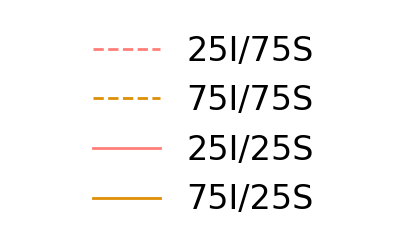

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

# ===================================================================
# --- USER EDITABLE SECTION --- (just run this locally in a notebook)
# ===================================================================

save_dir = '/Users/jinjiang-macair/Desktop'

# 1. Set the labels for your legend
legend_labels = [
    'Block A (25I/75S)',
    'Block B (75I/75S)',
    'Block C (25I/25S)',
    'Block D (75I/25S)'
]

# 2. Set the colors for each label
# (Using your poster's scheme: light red, light red, light blue, light blue)
legend_colors = [
    '#FF7E79',  
    '#DE8F05', 
    '#FF7E79',  
    '#DE8F05'
]

# 3. Set the line style for each label ('-' for solid, '--' for dashed)
legend_linestyles = [
    '--', 
    '--',
    '-',
    '-'
]

# 5. (Optional) Adjust styling
font_size = 24     # Font size
legend_title = None  # e.g., 'Block Type' or None
num_columns = 1      # How many columns for the legend (e.g., 1 or 2)
line_width = 2       # How thick the lines are

# ===================================================================
# --- SCRIPT LOGIC (No need to edit below) ---
# ===================================================================

print(f"Generating legend with {len(legend_labels)} items...")

# Create custom "handles" (the visual lines) for the legend
legend_handles = []
for i in range(len(legend_labels)):
    handle = Line2D(
        [0], [0],  # Dummy data
        color=legend_colors[i],
        linestyle=legend_linestyles[i],
        linewidth=line_width,
        label=legend_labels[i]
    )
    legend_handles.append(handle)

# Create a dummy figure
# We set a large enough size to draw the legend, then it will be cropped
fig = plt.figure(figsize=(5, 3))

# Create the legend in the center of the figure, with no frame
leg = fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='center',
    frameon=False,
    ncol=num_columns,
    fontsize=font_size,
    title=legend_title,
    title_fontsize=font_size
)

# Hide the (empty) plot axes
plt.axis('off')

# Save the figure, cropping to *just* the legend's bounding box
save_path = os.path.join(save_dir, 'legend.png')
fig.savefig(
    save_path,
    dpi=300,
    bbox_inches=leg.get_window_extent().transformed(fig.dpi_scale_trans.inverted()),
    pad_inches=0.1,  # Add a little padding
    transparent=False # Use a transparent background (true) or a white one (false)
)

plt.close(fig)

print(f"\n✅ Legend saved successfully!")
print(f"File: {save_path}")
print("You can now drag this file into your poster software (e.g., PowerPoint).")

make circle legends

Generating legend with 1 items...


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jinjiang-macair/Desktop/legend_circles.png'

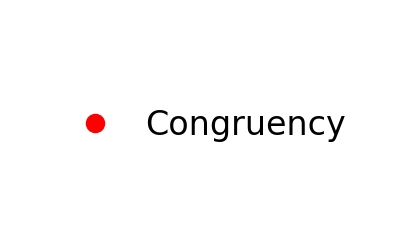

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

# ===================================================================
# --- USER EDITABLE SECTION ---
# ===================================================================

save_dir = '/Users/jinjiang-macair/Desktop'

# 1. Set the labels for your legend
legend_labels = [
    'Congruency'
]

# 2. Set the colors for each label's circle
legend_colors = [
    'red'  # Color for 'Congruent'
]

# 3. Set the fill style for each circle ('full' for filled, 'none' for empty)
# This replaces the solid/dashed line styles.
legend_fillstyles = [
    'full' # 'Congruent' will be a filled circle
]

# 5. (Optional) Adjust styling
font_size = 24       # Font size
marker_size = 12       # How big the circles are
marker_edgewidth = 2   # How thick the circle outline is
legend_title = None    # e.g., 'Block Type' or None
num_columns = 1        # How many columns for the legend (e.g., 1 or 2)

# ===================================================================
# --- SCRIPT LOGIC (No need to edit below) ---
# ===================================================================

print(f"Generating legend with {len(legend_labels)} items...")

# Create custom "handles" (the visual circles) for the legend
legend_handles = []
for i in range(len(legend_labels)):
    handle = Line2D(
        [0], [0],                  # Dummy data
        marker='o',                # Set marker to a circle
        linestyle='None',          # Hide the line
        color=legend_colors[i],    # This sets the edge color (and face color if 'full')
        fillstyle=legend_fillstyles[i], # Use the fill style from our list
        markersize=marker_size,
        markeredgewidth=marker_edgewidth,
        label=legend_labels[i]
    )
    legend_handles.append(handle)

# Create a dummy figure
# We set a large enough size to draw the legend, then it will be cropped
fig = plt.figure(figsize=(5, 3))

# Create the legend in the center of the figure, with no frame
leg = fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='center',
    frameon=False,
    ncol=num_columns,
    fontsize=font_size,
    title=legend_title,
    title_fontsize=font_size,
    # This can help align the text and markers nicely
    handletextpad=0.5 
)

# Hide the (empty) plot axes
plt.axis('off')

# Save the figure, cropping to *just* the legend's bounding box
save_path = os.path.join(save_dir, 'legend_circles.png') # Changed filename
fig.savefig(
    save_path,
    dpi=300,
    bbox_inches=leg.get_window_extent().transformed(fig.dpi_scale_trans.inverted()),
    pad_inches=0.1,  # Add a little padding
    transparent=False # Use a transparent background (true) or a white one (false)
)

plt.close(fig)

print(f"\n✅ Legend saved successfully!")
print(f"File: {save_path}")
print("You can now drag this file into your poster software (e.g., PowerPoint).")